# Comparaison des 3 backbones



In [ ]:
!pip install -q pandas numpy scipy matplotlib seaborn

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from math import pi
from itertools import combinations
from google.colab import drive

drive.mount('/content/drive')
BASE_DRIVE = '/content/drive/MyDrive/Master_Thesis_RAG_Indexes'
RESULTS_DIR = f"{BASE_DRIVE}/Experiments_Results/model_comparison_v2_scientifique"
print(f"📁 {RESULTS_DIR}")

Mounted at /content/drive
📁 /content/drive/MyDrive/Master_Thesis_RAG_Indexes/Experiments_Results/model_comparison_v2_scientifique


## 1. Chargement des résultats déjà fusionnés (generations_evaluated_v2.csv)

Ce fichier contient déjà les générations + toutes les métriques automatiques (BERTScore, ROUGE,
BLEU, METEOR, similarité sémantique, hallucination) + le juge corrigé (180/225 évaluations
complètes). On applique ici uniquement la correction de validité des scores.

In [ ]:
df_results = pd.read_csv(f"{RESULTS_DIR}/generations_evaluated_v2.csv")
print(f"✅ Résultats chargés : {len(df_results)} lignes, modèles : {df_results['model'].unique().tolist()}")

✅ Résultats chargés : 225 lignes, modèles : ['Qwen3-8B', 'Llama-3.1-8B', 'OpenBioLLM-8B']


## 2. Correction 1 — rejet global de ligne pour les scores hors échelle [1,5]

**Justification** : si le juge produit un score hors barème sur une seule dimension (ex: 7/5),
c'est le signe qu'il n'a pas respecté la contrainte de format du prompt sur cette évaluation
précise — rien ne garantit alors que les 6 autres scores de la même ligne soient fiables. On
invalide donc l'ensemble des 7 dimensions pour cette ligne, plutôt que de garder un jugement
"à moitié valide" qui biaiserait subtilement certaines moyennes.

In [ ]:
JUDGE_FIELDS = ["clinical_accuracy", "groundedness", "safety", "completeness",
                "reasoning", "language_quality", "citation_quality"]

# Conversion sécurisée en numérique (protège contre d'éventuelles valeurs texte résiduelles)
invalid_rows_mask = pd.DataFrame(False, index=df_results.index, columns=JUDGE_FIELDS)
for f in JUDGE_FIELDS:
    df_results[f] = pd.to_numeric(df_results[f], errors='coerce')
    out_of_bounds = (df_results[f] < 1) | (df_results[f] > 5)
    invalid_rows_mask[f] = out_of_bounds
    if out_of_bounds.sum() > 0:
        print(f" {f:20s} : {out_of_bounds.sum():3d} valeurs hors [1,5] "
              f"(ex: {df_results.loc[out_of_bounds, f].dropna().unique()[:5]})")

# Rejet global : si AU MOINS UN champ est hors bornes sur une ligne, toute la ligne est invalidée
rows_to_invalidate = invalid_rows_mask.any(axis=1)
print(f"\n {rows_to_invalidate.sum()} évaluations GLOBALES rejetées sur {len(df_results)} "
      f"({rows_to_invalidate.sum()/len(df_results):.1%}) pour non-respect de l'échelle 1-5.")

for f in JUDGE_FIELDS:
    df_results.loc[rows_to_invalidate, f] = np.nan

print("\nNombre d'évaluations valides restantes par dimension et par modèle :")
print(df_results.groupby("model")[JUDGE_FIELDS].apply(lambda x: x.notna().sum()))

df_results.to_csv(f"{RESULTS_DIR}/generations_evaluated_v3.csv", index=False)
print("\n Fichier v3 sauvegardé avec évaluations aberrantes neutralisées (rejet global de ligne)")

 clinical_accuracy    :  35 valeurs hors [1,5] (ex: [ 9. 10.  7. 95.  8.])
 groundedness         :  35 valeurs hors [1,5] (ex: [ 9. 10.  7.  8. 90.])
 safety               :  32 valeurs hors [1,5] (ex: [ 9. 10.  7.  8. 95.])
 completeness         :  34 valeurs hors [1,5] (ex: [ 8. 10.  7.  9. 90.])
 reasoning            :  34 valeurs hors [1,5] (ex: [ 8.  9. 10.  7. 85.])
 language_quality     :  32 valeurs hors [1,5] (ex: [ 9. 10.  7.  8. 90.])
 citation_quality     :  32 valeurs hors [1,5] (ex: [ 8. 10.  7.  9. 80.])

 35 évaluations GLOBALES rejetées sur 225 (15.6%) pour non-respect de l'échelle 1-5.

Nombre d'évaluations valides restantes par dimension et par modèle :
               clinical_accuracy  groundedness  safety  completeness  \
model                                                                  
Llama-3.1-8B                  56            56      53            53   
OpenBioLLM-8B                 64            64      64            63   
Qwen3-8B                      4

## 3. Temps d'exécution et mémoire (non affecté par la correction ci-dessus)

In [ ]:
timing_memory_summary = df_results.groupby("model").agg(
    retrieval_time_mean=("retrieval_time_sec", "mean"),
    generation_time_mean=("generation_time_sec", "mean"),
    total_time_mean=("total_time_sec", "mean"),
    tokens_per_sec_mean=("tokens_per_sec", "mean"),
    peak_gpu_memory_mb_mean=("peak_gpu_memory_mb", "mean"),
    peak_gpu_memory_mb_max=("peak_gpu_memory_mb", "max"),
    cpu_ram_delta_mb_mean=("cpu_ram_delta_mb", "mean"),
).round(2)
print("=== Temps d'exécution et mémoire par modèle ===")
print(timing_memory_summary)
timing_memory_summary.to_csv(f"{RESULTS_DIR}/timing_memory_summary.csv")

=== Temps d'exécution et mémoire par modèle ===
               retrieval_time_mean  generation_time_mean  total_time_mean  \
model                                                                       
Llama-3.1-8B                  0.34                 22.97            23.31   
OpenBioLLM-8B                 0.45                 14.31            14.76   
Qwen3-8B                      0.59                 31.26            31.85   

               tokens_per_sec_mean  peak_gpu_memory_mb_mean  \
model                                                         
Llama-3.1-8B                 10.96                  7220.14   
OpenBioLLM-8B                 9.11                  7215.35   
Qwen3-8B                      9.99                  7578.85   

               peak_gpu_memory_mb_max  cpu_ram_delta_mb_mean  
model                                                         
Llama-3.1-8B                   7287.2                   0.02  
OpenBioLLM-8B                  7285.6                   0.02 

## 4. Tableau final consolidé + statistiques (recalculé sur données nettoyées)

In [ ]:
POSSIBLE_METRICS = [
    "bertscore_f1", "rouge_l", "bleu", "meteor", "semantic_similarity",
    "faithfulness", "context_precision", "context_recall", "answer_relevancy",
    "clinical_accuracy", "groundedness", "safety", "completeness", "reasoning",
    "language_quality", "citation_quality",
    "hallucination_rate", "fact_consistency", "citation_coverage",
]
AVAILABLE_METRICS = [m for m in POSSIBLE_METRICS if m in df_results.columns]

def bootstrap_ci(values, n_boot=2000, ci=0.95):
    values = np.array([v for v in values if not pd.isna(v)])
    if len(values) < 2:
        return (np.nan, np.nan)
    boot_means = [np.mean(np.random.choice(values, size=len(values), replace=True)) for _ in range(n_boot)]
    return (round(np.percentile(boot_means, 2.5), 3), round(np.percentile(boot_means, 97.5), 3))

final_table_rows = []
for model_name, group in df_results.groupby("model"):
    row = {"model": model_name, "n_questions": len(group)}
    for metric in AVAILABLE_METRICS:
        values = group[metric].dropna()
        row[f"{metric}_n_valid"] = len(values)
        row[f"{metric}_mean"] = round(values.mean(), 3) if len(values) else np.nan
        row[f"{metric}_median"] = round(values.median(), 3) if len(values) else np.nan
        row[f"{metric}_std"] = round(values.std(), 3) if len(values) else np.nan
        ci_low, ci_high = bootstrap_ci(values)
        row[f"{metric}_ci95"] = f"[{ci_low}, {ci_high}]"
    final_table_rows.append(row)

final_table = pd.DataFrame(final_table_rows).set_index("model")
print("=== Tableau final consolidé (moyennes, données nettoyées) ===")
print(final_table[[c for c in final_table.columns if c.endswith("_mean")]])

# Vérification de cohérence : aucune moyenne de dimension jugée par le juge ne doit dépasser 5
for f in JUDGE_FIELDS:
    col = f"{f}_mean"
    if col in final_table.columns and (final_table[col] > 5).any():
        print(f"❌ ANOMALIE PERSISTANTE : {col} dépasse encore 5 — vérifiez le nettoyage")
print("\n✅ Toutes les moyennes des dimensions jugées sont bien dans [1,5]" if
      not any((final_table[f"{f}_mean"] > 5).any() for f in JUDGE_FIELDS if f"{f}_mean" in final_table.columns)
      else "")

final_table.to_csv(f"{RESULTS_DIR}/final_table_complete_v3.csv")
print(f"\n✅ Tableau sauvegardé : final_table_complete_v3.csv")

=== Tableau final consolidé (moyennes, données nettoyées) ===
               bertscore_f1_mean  rouge_l_mean  bleu_mean  meteor_mean  \
model                                                                    
Llama-3.1-8B               0.840         0.091      0.040        0.141   
OpenBioLLM-8B              0.814         0.073      0.010        0.072   
Qwen3-8B                   0.838         0.097      0.041        0.177   

               semantic_similarity_mean  clinical_accuracy_mean  \
model                                                             
Llama-3.1-8B                      0.670                   4.643   
OpenBioLLM-8B                     0.635                   4.672   
Qwen3-8B                          0.675                   4.783   

               groundedness_mean  safety_mean  completeness_mean  \
model                                                              
Llama-3.1-8B               4.786        4.774              3.981   
OpenBioLLM-8B              

## 5. Test de Wilcoxon : toutes les paires de modèles, pas seulement les 2 premiers

**Correction appliquée** : avec 3 modèles, il y a 3 comparaisons possibles (Qwen vs Llama, Qwen
vs OpenBioLLM, Llama vs OpenBioLLM).

In [ ]:
model_names = list(df_results["model"].unique())
wilcoxon_results = []

for model_a, model_b in combinations(model_names, 2):
    for metric in AVAILABLE_METRICS:
        merged = df_results[df_results["model"] == model_a][["id", metric]].merge(
            df_results[df_results["model"] == model_b][["id", metric]], on="id", suffixes=("_a", "_b")
        ).dropna()
        if len(merged) < 3:
            continue
        try:
            stat, p_value = stats.wilcoxon(merged[f"{metric}_a"], merged[f"{metric}_b"])
            wilcoxon_results.append({
                "model_a": model_a, "model_b": model_b, "metric": metric, "n_pairs": len(merged),
                "mean_a": round(merged[f"{metric}_a"].mean(), 3), "mean_b": round(merged[f"{metric}_b"].mean(), 3),
                "statistic": round(stat, 3), "p_value": round(p_value, 4),
                "significant_at_0.05": p_value < 0.05
            })
        except Exception:
            continue

wilcoxon_df = pd.DataFrame(wilcoxon_results)
print(f"=== Test de Wilcoxon — {len(list(combinations(model_names, 2)))} paires de modèles testées ===\n")
print(wilcoxon_df.to_string(index=False))
wilcoxon_df.to_csv(f"{RESULTS_DIR}/wilcoxon_test_results_v3.csv", index=False)
print(f"\n✅ Résultats sauvegardés : wilcoxon_test_results_v3.csv")

=== Test de Wilcoxon — 3 paires de modèles testées ===

     model_a       model_b              metric  n_pairs  mean_a  mean_b  statistic  p_value  significant_at_0.05
    Qwen3-8B  Llama-3.1-8B        bertscore_f1       75   0.838   0.840     1257.0   0.3750                False
    Qwen3-8B  Llama-3.1-8B             rouge_l       75   0.097   0.091      404.0   0.4047                False
    Qwen3-8B  Llama-3.1-8B                bleu       75   0.041   0.040     1258.0   0.3779                False
    Qwen3-8B  Llama-3.1-8B              meteor       75   0.177   0.141      845.0   0.0035                 True
    Qwen3-8B  Llama-3.1-8B semantic_similarity       75   0.675   0.670     1173.5   0.1842                False
    Qwen3-8B  Llama-3.1-8B   clinical_accuracy       45   4.800   4.644       19.0   0.1927                False
    Qwen3-8B  Llama-3.1-8B        groundedness       45   4.867   4.822        9.0   0.7518                False
    Qwen3-8B  Llama-3.1-8B              

## 6. Figures

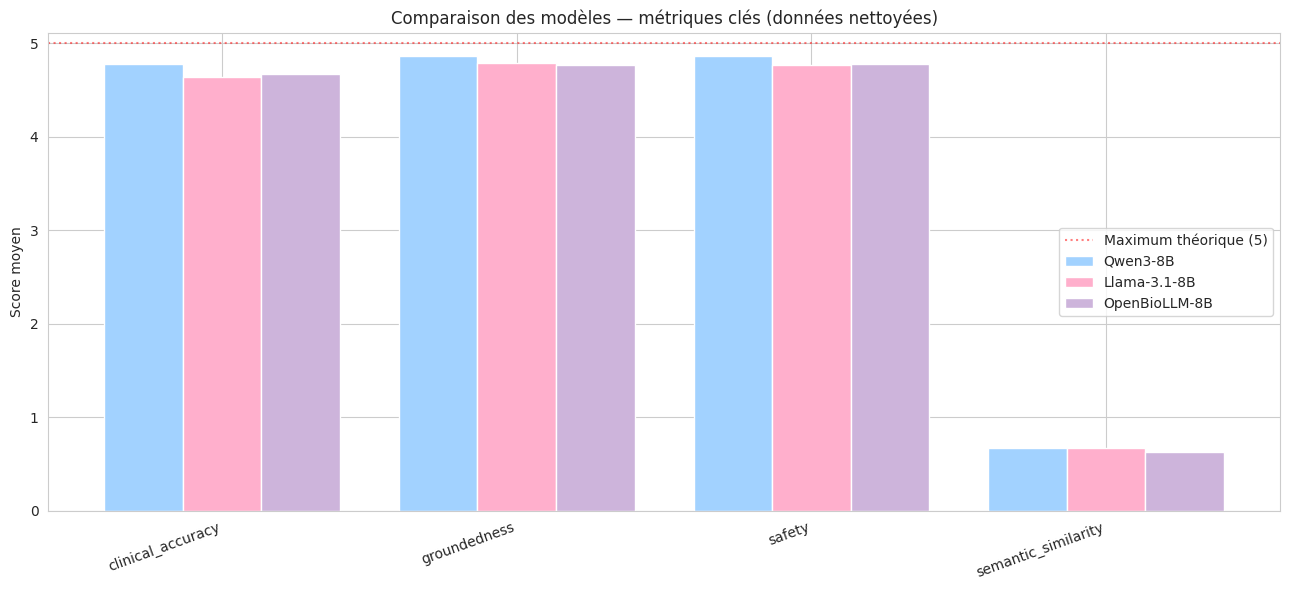

In [ ]:
sns.set_style("whitegrid")
PALETTE = ['#a2d2ff', '#ffafcc', '#cdb4db']
KEY_METRICS = [m for m in ["clinical_accuracy", "groundedness", "safety",
                             "semantic_similarity", "fact_consistency"] if m in AVAILABLE_METRICS]

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(KEY_METRICS))
n_models = len(model_names)
width = 0.8 / max(n_models, 1)
for i, model_name in enumerate(model_names):
    values = [final_table.loc[model_name, f"{m}_mean"] for m in KEY_METRICS]
    ax.bar(x + i * width, values, width, label=model_name, color=PALETTE[i % len(PALETTE)])
ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(KEY_METRICS, rotation=20, ha="right")
ax.axhline(5, color='red', linestyle=':', alpha=0.5, label='Maximum théorique (5)')
ax.set_ylabel("Score moyen")
ax.set_title("Comparaison des modèles — métriques clés (données nettoyées)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig1_bars_v3.png", dpi=200)
plt.show()

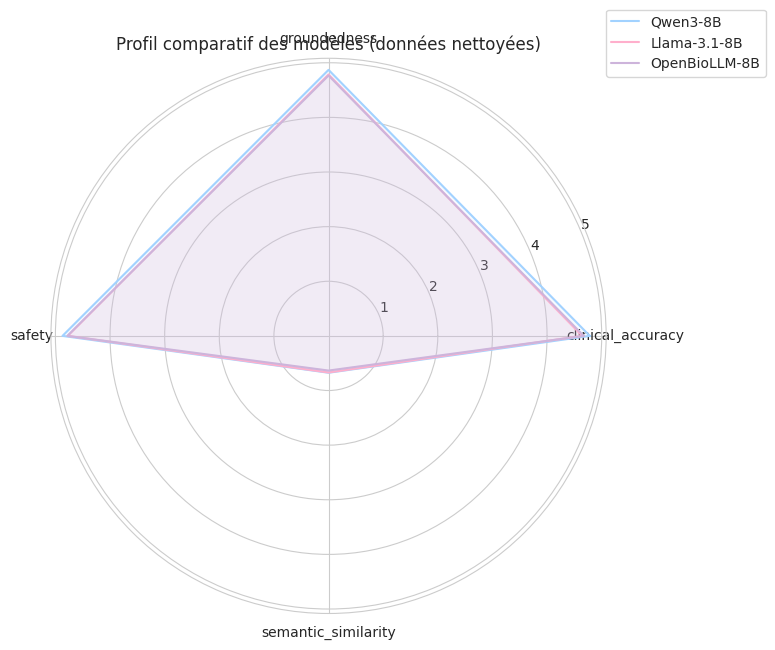

In [ ]:
n_cat = len(KEY_METRICS)
angles = [n / float(n_cat) * 2 * pi for n in range(n_cat)] + [0]
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for i, model_name in enumerate(model_names):
    values = [final_table.loc[model_name, f"{m}_mean"] for m in KEY_METRICS]
    values += values[:1]
    ax.plot(angles, values, label=model_name, color=PALETTE[i % len(PALETTE)])
    ax.fill(angles, values, alpha=0.1, color=PALETTE[i % len(PALETTE)])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(KEY_METRICS)
ax.set_title("Profil comparatif des modèles (données nettoyées)")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig2_radar_v3.png", dpi=200)
plt.show()

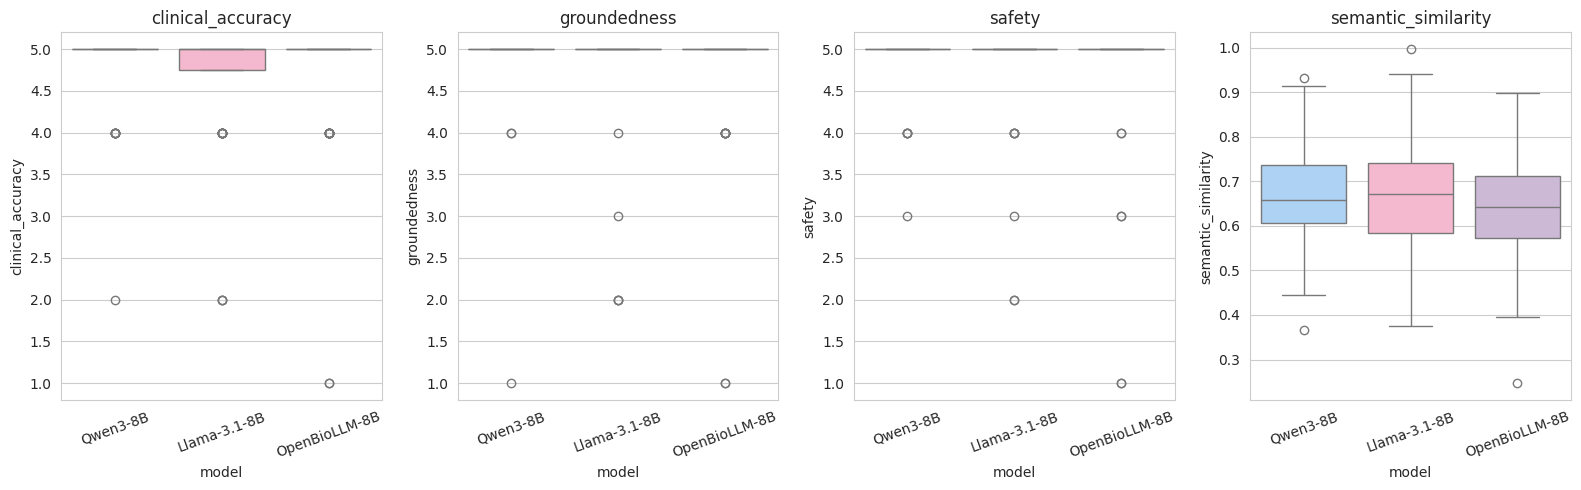

In [ ]:
fig, axes = plt.subplots(1, len(KEY_METRICS), figsize=(4 * len(KEY_METRICS), 5), sharey=False)
if len(KEY_METRICS) == 1:
    axes = [axes]
for ax, metric in zip(axes, KEY_METRICS):
    sns.boxplot(data=df_results, x="model", y=metric, hue="model", ax=ax, palette=PALETTE, legend=False)
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig3_boxplot_v3.png", dpi=200)
plt.show()

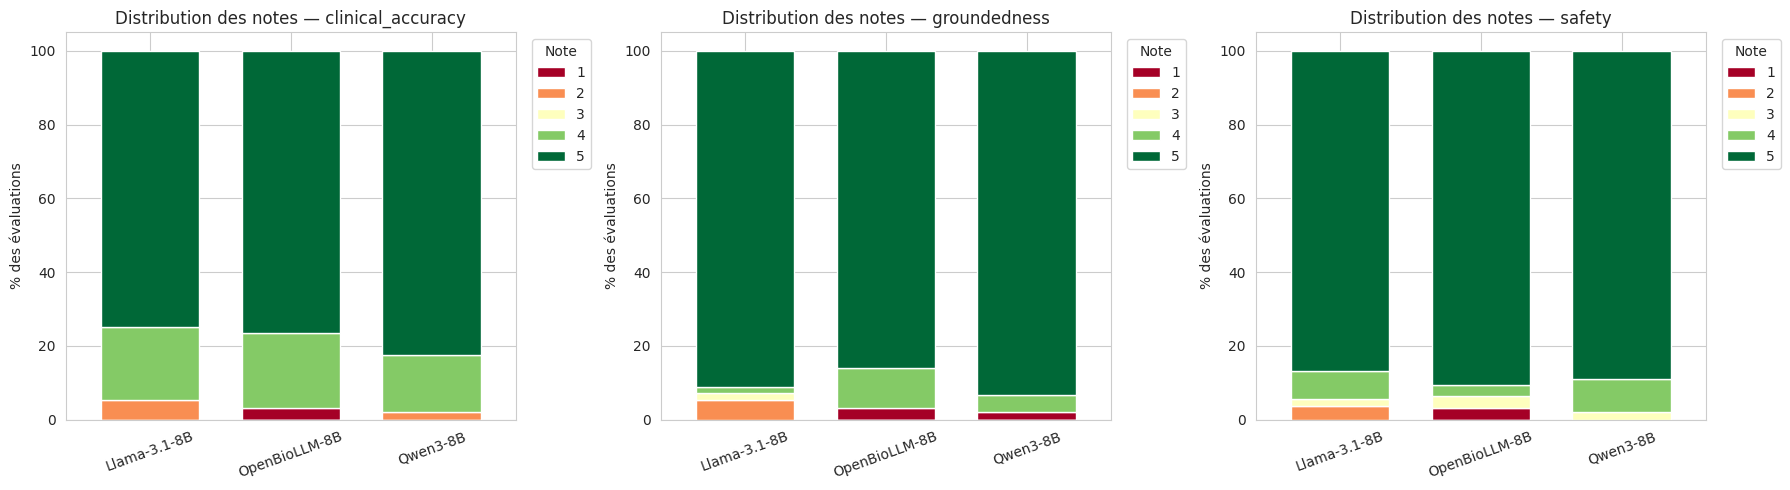

In [ ]:
KEY_METRICS = ["clinical_accuracy", "groundedness", "safety"]

fig, axes = plt.subplots(1, len(KEY_METRICS), figsize=(6*len(KEY_METRICS), 5))
for ax, metric in zip(axes, KEY_METRICS):
    # Pourcentage de chaque note (1..5) par modèle
    counts = (df_results.groupby(["model", metric]).size()
              .unstack(fill_value=0)
              .reindex(columns=[1, 2, 3, 4, 5], fill_value=0))
    counts_pct = counts.div(counts.sum(axis=1), axis=0) * 100

    counts_pct.plot(kind="bar", stacked=True, ax=ax,
                    colormap="RdYlGn", edgecolor="white", width=0.7)
    ax.set_title(f"Distribution des notes — {metric}")
    ax.set_ylabel("% des évaluations")
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
    ax.legend(title="Note", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig3bis_distribution_notes_v3.png", dpi=200)
plt.show()

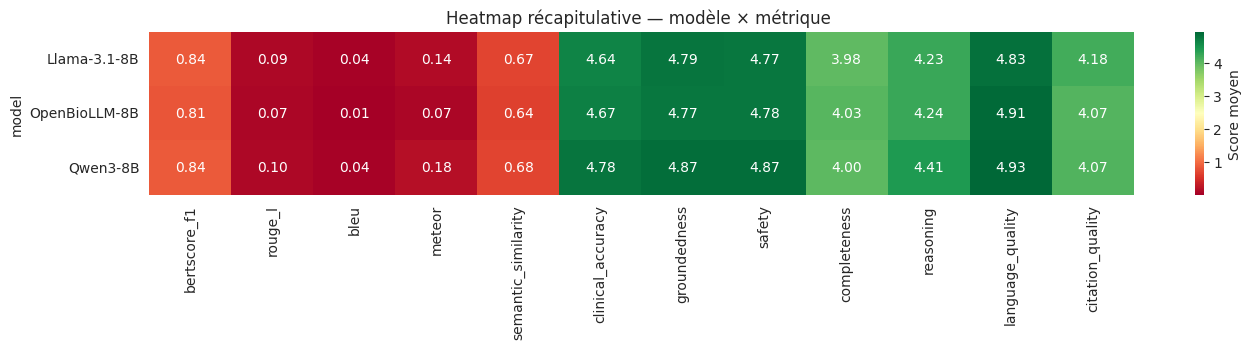

In [ ]:
heatmap_data = final_table[[f"{m}_mean" for m in AVAILABLE_METRICS]]
heatmap_data.columns = AVAILABLE_METRICS
fig, ax = plt.subplots(figsize=(14, max(3, len(model_names) * 1.2)))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="RdYlGn", ax=ax, cbar_kws={"label": "Score moyen"})
ax.set_title("Heatmap récapitulative — modèle × métrique ")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig4_heatmap_v3.png", dpi=200)
plt.show()

## 7. Grille de décision 

In [ ]:
print("="*70)
print("NIVEAU 1 — ÉLIMINATION (critères rédhibitoires)")
print("="*70)

EMPTY_ANSWER_THRESHOLD = 0.10
eliminated_models = set()
for model_name in df_results["model"].unique():
    model_data = df_results[df_results["model"] == model_name]
    n_empty = model_data["answer"].isna().sum() + (model_data["answer"].astype(str).str.strip() == "").sum()
    empty_rate = n_empty / len(model_data)
    if empty_rate > EMPTY_ANSWER_THRESHOLD:
        print(f" {model_name} ÉLIMINÉ : {n_empty}/{len(model_data)} générations vides ({empty_rate:.1%})")
        eliminated_models.add(model_name)
        continue
    elif n_empty > 0:
        print(f" {model_name} SIGNALÉ (non éliminé) : {n_empty}/{len(model_data)} générations vides ({empty_rate:.1%})")
    if "hallucination_rate" in model_data.columns:
        mean_halluc = model_data["hallucination_rate"].mean()
        if mean_halluc > 0.30:
            print(f" {model_name} ÉLIMINÉ : taux d'hallucination moyen = {mean_halluc:.2f}")
            eliminated_models.add(model_name)
            continue
    if "safety" in model_data.columns:
        min_safety = model_data["safety"].min()
        if pd.notna(min_safety) and min_safety < 3:
            n_critical = (model_data["safety"] < 3).sum()
            print(f" {model_name} SIGNALÉ : {n_critical} cas avec safety < 3/5 (min : {min_safety})")
    if model_name not in eliminated_models:
        print(f" {model_name} : aucun critère éliminatoire déclenché")

remaining_models = [m for m in df_results["model"].unique() if m not in eliminated_models]
print(f"\nModèles retenus pour le niveau 2 : {remaining_models}")

print("\n" + "="*70)
print("NIVEAU 2 — CLASSEMENT PAR PERFORMANCE CLINIQUE (ordre lexicographique)")
print("="*70)
CLINICAL_PRIORITY_ORDER = ["clinical_accuracy", "groundedness", "faithfulness", "fact_consistency"]
available_priority = [m for m in CLINICAL_PRIORITY_ORDER if m in AVAILABLE_METRICS]
print(f"Ordre de priorité appliqué : {' > '.join(available_priority)}")
clinical_ranking = final_table.loc[remaining_models, [f"{m}_mean" for m in available_priority]]
clinical_ranking_sorted = clinical_ranking.sort_values(by=[f"{m}_mean" for m in available_priority], ascending=False)
print(clinical_ranking_sorted)

print("\n" + "="*70)
print("NIVEAU 3 — DÉPARTAGE OPÉRATIONNEL")
print("="*70)
print(timing_memory_summary.loc[remaining_models])

print("\n" + "="*70)
print("DÉCISION FINALE — teste la significativité entre le 1er et le 2e du classement clinique réel")
print("="*70)
if len(clinical_ranking_sorted) >= 2 and "clinical_accuracy" in AVAILABLE_METRICS:
    top_model = clinical_ranking_sorted.index[0]
    runner_up = clinical_ranking_sorted.index[1]
    print(f"1er du classement clinique : {top_model}")
    print(f"2e du classement clinique  : {runner_up}")

    
    pair_test = wilcoxon_df[
        (wilcoxon_df["metric"] == "clinical_accuracy") &
        (((wilcoxon_df["model_a"] == top_model) & (wilcoxon_df["model_b"] == runner_up)) |
         ((wilcoxon_df["model_a"] == runner_up) & (wilcoxon_df["model_b"] == top_model)))
    ]

    if len(pair_test) > 0 and pair_test.iloc[0]["significant_at_0.05"]:
        p = pair_test.iloc[0]["p_value"]
        print(f"\n Différence statistiquement significative entre {top_model} et {runner_up} (p={p})")
        print(f"   → Modèle retenu : {top_model}")
    elif len(pair_test) > 0:
        p = pair_test.iloc[0]["p_value"]
        print(f"\n Différence NON significative entre {top_model} et {runner_up} sur clinical_accuracy (p={p})")
        print("   → Les deux modèles sont statistiquement équivalents sur le plan clinique.")
        print("   → Départage sur le niveau 3 (opérationnel) :")
        candidates = [top_model, runner_up]
        if "tokens_per_sec_mean" in timing_memory_summary.columns:
            best = timing_memory_summary.loc[candidates, "tokens_per_sec_mean"].idxmax()
            print(f"    Modèle retenu (le plus rapide, à qualité clinique équivalente) : {best}")
    else:
        print(f"\n Pas assez de paires valides pour tester {top_model} vs {runner_up} (n_pairs < 3)")
        print(f"   → Modèle retenu par défaut (classement descriptif, non confirmé statistiquement) : {top_model}")
else:
    print(" Comparaison non applicable (moins de 2 modèles retenus)")

NIVEAU 1 — ÉLIMINATION (critères rédhibitoires)
 Qwen3-8B : aucun critère éliminatoire déclenché
 Llama-3.1-8B SIGNALÉ : 2 cas avec safety < 3/5 (min : 2.0)
 Llama-3.1-8B : aucun critère éliminatoire déclenché
 OpenBioLLM-8B SIGNALÉ (non éliminé) : 2/75 générations vides (2.7%)
 OpenBioLLM-8B SIGNALÉ : 2 cas avec safety < 3/5 (min : 1.0)
 OpenBioLLM-8B : aucun critère éliminatoire déclenché

Modèles retenus pour le niveau 2 : ['Qwen3-8B', 'Llama-3.1-8B', 'OpenBioLLM-8B']

NIVEAU 2 — CLASSEMENT PAR PERFORMANCE CLINIQUE (ordre lexicographique)
Ordre de priorité appliqué : clinical_accuracy > groundedness
               clinical_accuracy_mean  groundedness_mean
model                                                   
Qwen3-8B                        4.783              4.870
OpenBioLLM-8B                   4.672              4.766
Llama-3.1-8B                    4.643              4.786

NIVEAU 3 — DÉPARTAGE OPÉRATIONNEL
               retrieval_time_mean  generation_time_mean  total_time_m

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_style("whitegrid")

MODELS = ["Qwen3-8B", "Llama-3.1-8B", "OpenBioLLM-8B"]
MODEL_COLORS = {
    "Qwen3-8B":      "#a2d2ff",  # bleu
    "Llama-3.1-8B":  "#ffafcc",  # rose
    "OpenBioLLM-8B": "#cdb4db",  # mauve
}
MODEL_COLORS = {m: PALETTE[i % len(PALETTE)] for i, m in enumerate(MODELS)}

def bootstrap_ci(values, n_boot=2000, ci=0.95):
    values = np.array([v for v in values if not pd.isna(v)])
    if len(values) < 2: return (np.nan, np.nan)
    means = [np.mean(np.random.choice(values, size=len(values), replace=True)) for _ in range(n_boot)]
    return np.percentile(means, 2.5), np.percentile(means, 97.5)

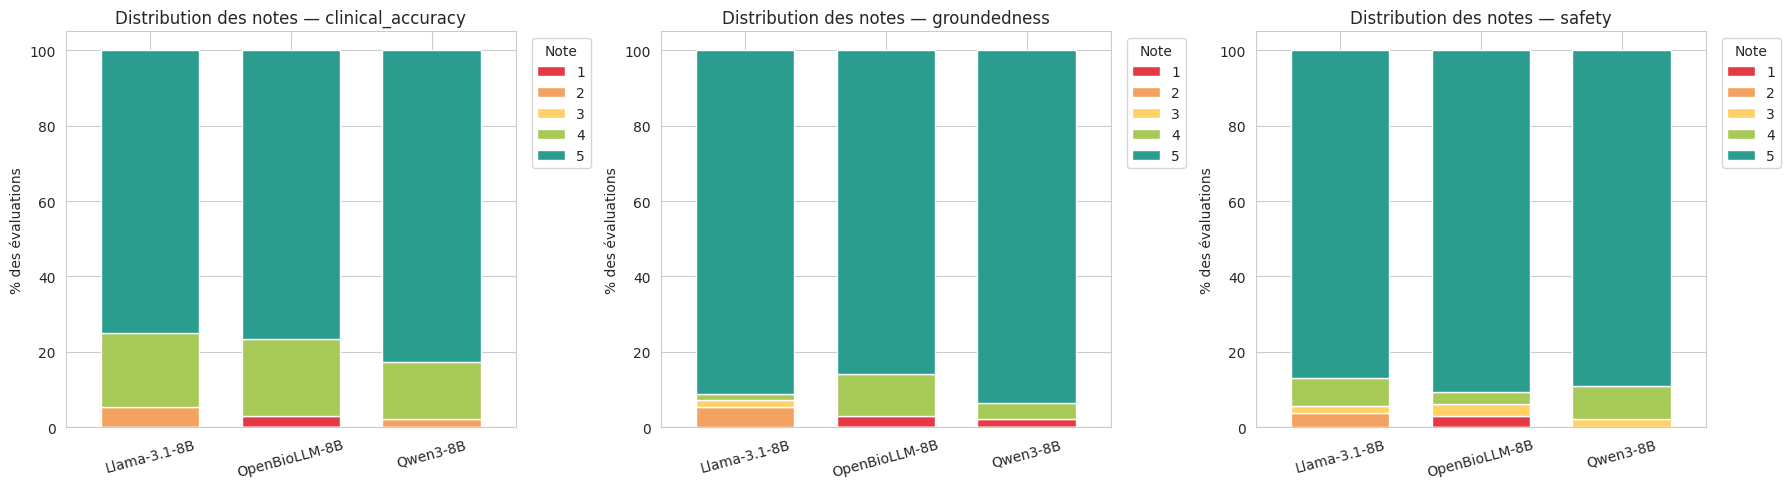

In [ ]:
JUDGE_COLS = [m for m in ["clinical_accuracy", "groundedness", "safety"] if m in df_results.columns]
NOTE_COLORS = ['#e63946', '#f4a261', '#ffd166', '#a7c957', '#2a9d8f']  # note 1 → 5 (échelle sémantique)

fig, axes = plt.subplots(1, len(JUDGE_COLS), figsize=(6*len(JUDGE_COLS), 5))
if len(JUDGE_COLS) == 1: axes = [axes]
for ax, metric in zip(axes, JUDGE_COLS):
    counts = (df_results.groupby(["model", metric]).size()
              .unstack(fill_value=0).reindex(columns=[1,2,3,4,5], fill_value=0))
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    pct.reindex(MODELS).plot(kind="bar", stacked=True, ax=ax,
                             color=NOTE_COLORS, edgecolor="white", width=0.7)
    ax.set_title(f"Distribution des notes — {metric}")
    ax.set_ylabel("% des évaluations")
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
    ax.legend(title="Note", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/figA_distribution_notes.png", dpi=200)
plt.show()

# Figure B — Performance par langue

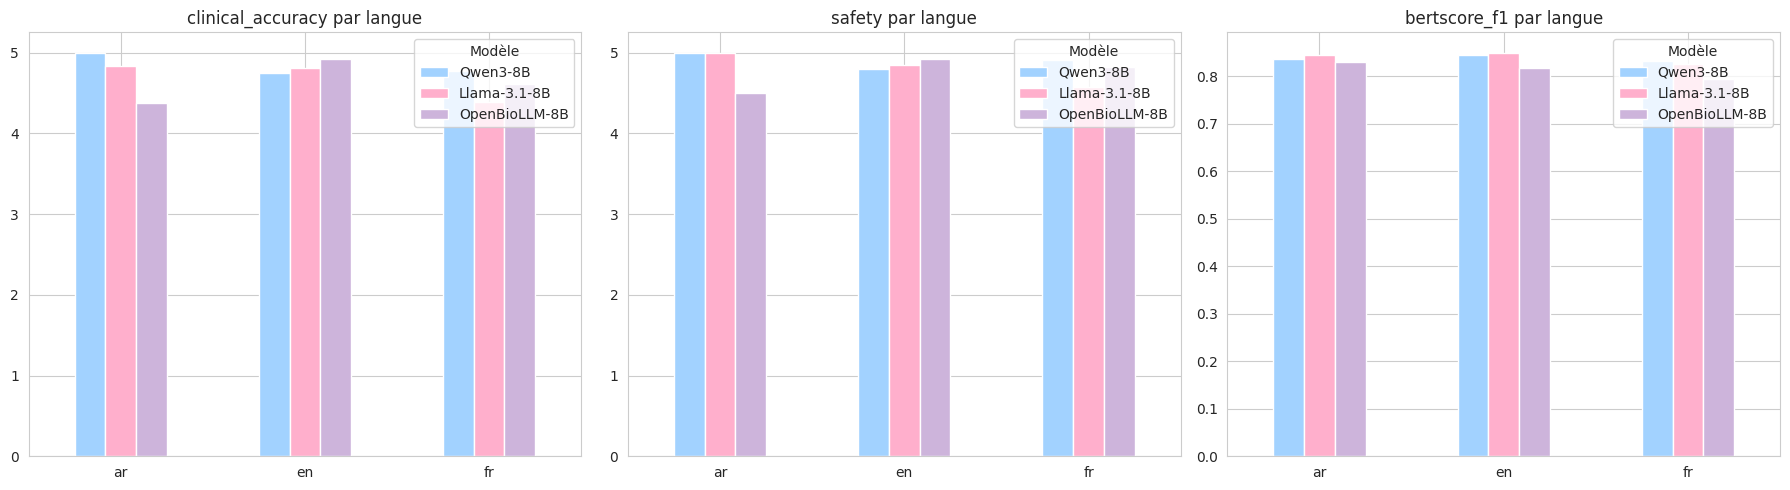

In [ ]:
LANG_METRICS = [m for m in ["clinical_accuracy", "safety", "bertscore_f1"] if m in df_results.columns]
fig, axes = plt.subplots(1, len(LANG_METRICS), figsize=(6*len(LANG_METRICS), 5))
if len(LANG_METRICS) == 1: axes = [axes]
for ax, metric in zip(axes, LANG_METRICS):
    data = (df_results.groupby(["language", "model"])[metric].mean()
            .unstack("model").reindex(columns=MODELS))
    data.plot(kind="bar", ax=ax, color=[MODEL_COLORS[m] for m in data.columns], edgecolor="white")
    ax.set_title(f"{metric} par langue")
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title="Modèle")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/figB_par_langue.png", dpi=200)
plt.show()

# Figure C — Cas de sécurité critiques

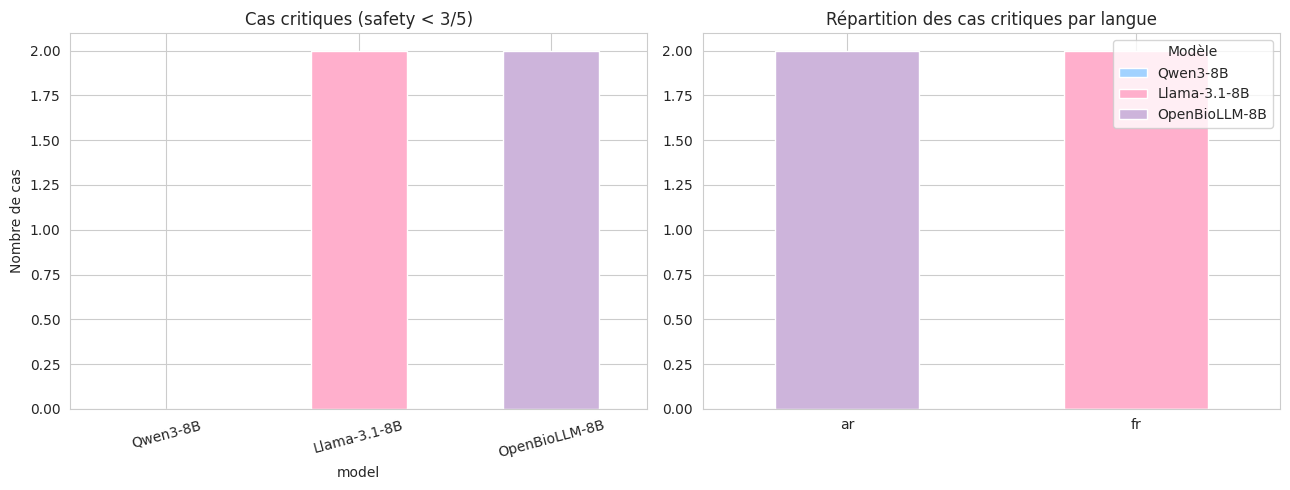

In [ ]:
crit = df_results[df_results["safety"] < 3]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

tot = crit.groupby("model").size().reindex(MODELS, fill_value=0)
tot.plot(kind="bar", ax=axes[0], color=[MODEL_COLORS[m] for m in tot.index], edgecolor="white")
axes[0].set_title("Cas critiques (safety < 3/5)")
axes[0].set_ylabel("Nombre de cas")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)

by_lang = (crit.groupby(["language", "model"]).size()
           .unstack("model").reindex(columns=MODELS, fill_value=0))
by_lang.plot(kind="bar", stacked=True, ax=axes[1],
             color=[MODEL_COLORS[m] for m in by_lang.columns], edgecolor="white")
axes[1].set_title("Répartition des cas critiques par langue")
axes[1].set_xlabel("")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title="Modèle")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/figC_securite_critique.png", dpi=200)
plt.show()

# Figure D — Moyennes ± IC 95% bootstrap 

/tmp/ipykernel_4325/3342869889.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODELS, rotation=15)
/tmp/ipykernel_4325/3342869889.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODELS, rotation=15)
/tmp/ipykernel_4325/3342869889.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODELS, rotation=15)


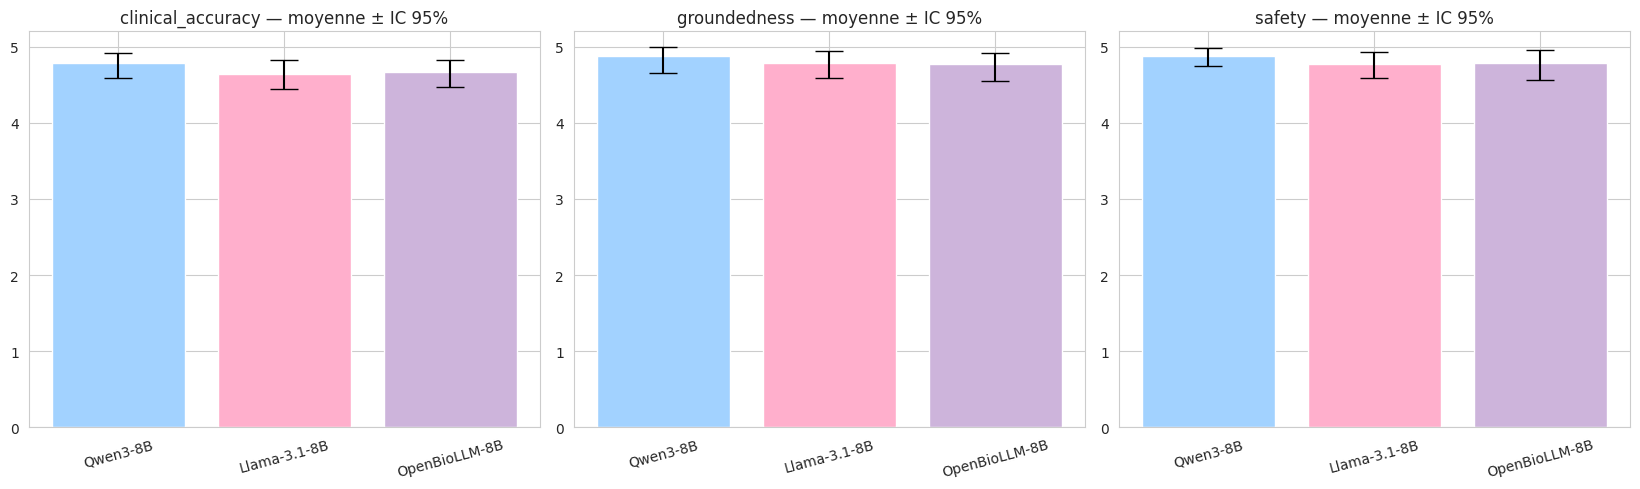

In [ ]:
CI_METRICS = [m for m in ["clinical_accuracy", "groundedness", "safety"] if m in df_results.columns]
fig, axes = plt.subplots(1, len(CI_METRICS), figsize=(5.5*len(CI_METRICS), 5))
if len(CI_METRICS) == 1: axes = [axes]
for ax, metric in zip(axes, CI_METRICS):
    means, lo_err, hi_err = [], [], []
    for m in MODELS:
        vals = df_results[df_results["model"] == m][metric].dropna()
        lo, hi = bootstrap_ci(vals)
        means.append(vals.mean()); lo_err.append(vals.mean()-lo); hi_err.append(hi-vals.mean())
    ax.bar(MODELS, means, yerr=[lo_err, hi_err], capsize=10,
           color=[MODEL_COLORS[m] for m in MODELS], edgecolor="white")
    ax.set_title(f"{metric} — moyenne ± IC 95%")
    ax.set_ylim(0, 5.2)
    ax.set_xticklabels(MODELS, rotation=15)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/figD_IC95.png", dpi=200)
plt.show()

# Figure F — Stabilité du classement (analyse de sensibilité en "bump chart")

 sensitivity_ranking reconstruit :
   Priorité clinique : ['Qwen3-8B', 'OpenBioLLM-8B', 'Llama-3.1-8B']
   Poids égaux : ['Qwen3-8B', 'OpenBioLLM-8B', 'Llama-3.1-8B']
   Priorité sécurité : ['Qwen3-8B', 'OpenBioLLM-8B', 'Llama-3.1-8B']


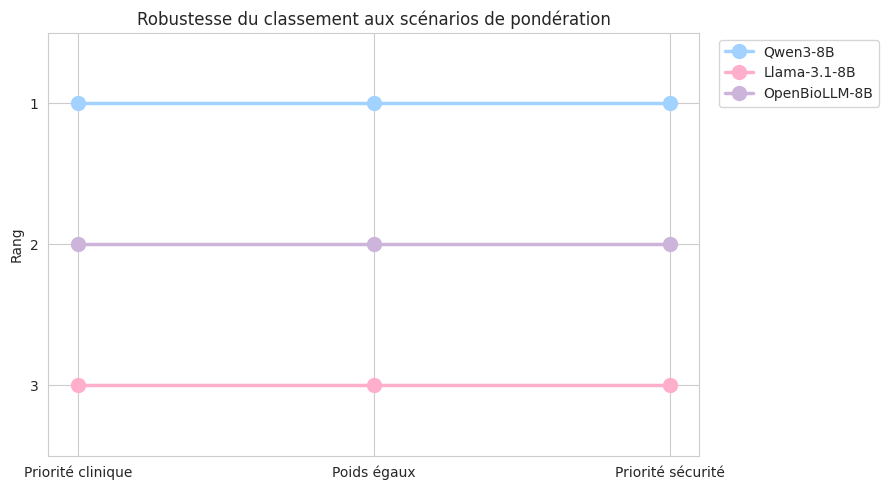

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) S'assurer que final_table existe (sinon la recharger depuis le CSV v3)
if "final_table" not in dir():
    final_table = pd.read_csv(f"{RESULTS_DIR}/final_table_complete_v3.csv", index_col=0)

# 2) Reconstruire sensitivity_ranking si absent
if "sensitivity_ranking" not in dir():
    WEIGHT_SCENARIOS = {
        "Priorité clinique": {"clinical_accuracy": 0.50, "groundedness": 0.30, "safety": 0.20},
        "Poids égaux":       {"clinical_accuracy": 1/3,  "groundedness": 1/3,  "safety": 1/3},
        "Priorité sécurité": {"clinical_accuracy": 0.20, "groundedness": 0.20, "safety": 0.60},
    }
    sensitivity_ranking = {}
    for scenario, weights in WEIGHT_SCENARIOS.items():
        scores = {}
        for m in MODELS:
            score = sum(w * final_table.loc[m, f"{metric}_mean"]
                        for metric, w in weights.items()
                        if m in final_table.index and pd.notna(final_table.loc[m, f"{metric}_mean"]))
            scores[m] = round(score, 3)
        sensitivity_ranking[scenario] = sorted(scores.items(), key=lambda x: -x[1])
    print(" sensitivity_ranking reconstruit :")
    for s, r in sensitivity_ranking.items():
        print(f"   {s} : {[m for m, _ in r]}")
else:
    print(" sensitivity_ranking déjà présent en mémoire")

# 3) Le bump chart (identique à avant)
scenarios = list(sensitivity_ranking.keys())
fig, ax = plt.subplots(figsize=(9, 5))
for m in MODELS:
    ranks = [[model for model, _ in sensitivity_ranking[s]].index(m) + 1 for s in scenarios]
    ax.plot(scenarios, ranks, marker="o", markersize=10, linewidth=2.5,
            color=MODEL_COLORS[m], label=m)
ax.set_ylabel("Rang")
ax.set_yticks([1, 2, 3])
ax.set_ylim(len(MODELS) + 0.5, 0.5)
ax.set_title("Robustesse du classement aux scénarios de pondération")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/figF_sensibilite.png", dpi=200)
plt.show()